# Embeddings Metrics
XGBoost e RNN Vanilla — preço vs preço + embeddings — retorno de 5 dias do ouro.
Validação com `TimeSeriesSplit`. Logging via W&B.

In [1]:
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import pandas as pd
import torch
import torch.nn as nn
import wandb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from xgboost import XGBRegressor

In [2]:
SEED          = 42
HORIZON       = 5
SEQ_LEN       = 20
N_SPLITS      = 2
VAL_FRAC      = 0.20
EPOCHS        = 60
BATCH_SIZE    = 64
LR            = 1e-3
RNN_HIDDEN    = 64
USE_WANDB     = False
WANDB_PROJECT = "gold-forecast"

OUTPUT_PATH    = Path("./out")
GOLD_DATA_PATH = OUTPUT_PATH / "final_gold_data_embeddings.parquet"

torch.manual_seed(SEED)
np.random.seed(SEED)

In [3]:
if USE_WANDB:
    run = wandb.init(
        project=WANDB_PROJECT,
        name="embeddings-metrics",
        config={
            "seed": SEED, "horizon": HORIZON, "seq_len": SEQ_LEN,
            "n_splits": N_SPLITS, "val_frac": VAL_FRAC,
            "epochs": EPOCHS, "batch_size": BATCH_SIZE,
            "lr": LR, "rnn_hidden": RNN_HIDDEN,
        },
    )

## 1. Dados

In [4]:
gold = pd.read_parquet(GOLD_DATA_PATH)
gold = gold.sort_values("timestamp").reset_index(drop=True)
print(gold.shape)
gold.head()

(6177, 12)


,timestamp,open,high,low,close,volume,currency,unit,headlines,emb_nomic_1d,emb_nomic_7d,emb_nomic_dev_1d_7d
0,2000-08-30,273.9,273.9,273.9,273.9,0,usd,ounce,Recalls Fuel Disclosure Debate / Deutsche Tele...,"[0.016506249085068703, 0.05451096221804619, -0...","[0.016722846776247025, 0.05469881370663643, -0...","[-0.00021659769117832184, -0.00018785148859024..."
1,2000-08-31,274.8,278.3,274.8,278.3,0,usd,ounce,Credit Suisse's Wheat Faces Deal / Regulators ...,"[0.0030195650178939104, 0.0543488971889019, -0...","[0.01358045730739832, 0.04626588523387909, -0....","[-0.010560892289504409, 0.008083011955022812, ..."
2,2000-09-01,277.0,277.0,277.0,277.0,0,usd,ounce,Nordstrom's Chief Resigns / Judge Dismisses Ca...,"[0.00742419995367527, 0.015169485472142696, -0...","[0.018122855573892593, 0.03499217331409454, -0...","[-0.010698655620217323, -0.019822687841951847,..."
3,2000-09-05,275.8,275.8,275.8,275.8,2,usd,ounce,Market Pace Slows After 10-Year Run / Clickman...,"[-0.015742214396595955, 0.0482579730451107, -0...","[0.011489766649901867, 0.03651130944490433, -0...","[-0.027231981046497822, 0.011746663600206375, ..."
4,2000-09-06,274.2,274.2,274.2,274.2,0,usd,ounce,France Telecom Profit Increases / Locale-Based...,"[0.01789318583905697, 0.039853937923908234, -0...","[0.016275350004434586, 0.03585308417677879, -0...","[0.0016178358346223831, 0.00400085374712944, -..."


In [5]:
gold["target"] = (gold["close"].shift(-HORIZON) - gold["close"]) / gold["close"]

In [6]:
for lag in [1, 2, 3, 5, 10, 21]:
    gold[f"ret_{lag}d"] = gold["close"].pct_change(lag)

gold["hl_ratio"]       = gold["high"] / gold["low"]
gold["co_ratio"]       = gold["close"] / gold["open"]
gold["close_position"] = (gold["close"] - gold["low"]) / (gold["high"] - gold["low"] + 1e-9)

for w in [5, 10, 21]:
    gold[f"ret_roll_mean_{w}d"] = gold["ret_1d"].rolling(w).mean()
    gold[f"ret_roll_std_{w}d"]  = gold["ret_1d"].rolling(w).std()

gold["volume_ratio"] = gold["volume"] / (gold["volume"].rolling(21).mean() + 1e-9)

price_features = [
    "ret_1d", "ret_2d", "ret_3d", "ret_5d", "ret_10d", "ret_21d",
    "hl_ratio", "co_ratio", "close_position",
    "ret_roll_mean_5d",  "ret_roll_std_5d",
    "ret_roll_mean_10d", "ret_roll_std_10d",
    "ret_roll_mean_21d", "ret_roll_std_21d",
    "volume_ratio",
]
print(f"Price features: {len(price_features)}")

Price features: 16


In [7]:
emb_dfs = []
for col in ["emb_nomic_1d", "emb_nomic_7d", "emb_nomic_dev_1d_7d"]:
    arr = np.stack(gold[col].values)
    emb_dfs.append(pd.DataFrame(arr, columns=[f"{col}_{i}" for i in range(arr.shape[1])], index=gold.index))

emb_df       = pd.concat(emb_dfs, axis=1)
emb_features = emb_df.columns.tolist()
all_features  = price_features + emb_features
print(f"Embedding features: {len(emb_features)} | Total: {len(all_features)}")

Embedding features: 2304 | Total: 2320


In [8]:
df = pd.concat([gold[["timestamp", "target"] + price_features], emb_df], axis=1)
df = df.dropna().reset_index(drop=True)
print(f"Linhas: {len(df)}")

Linhas: 6151


## 2. Helpers

In [9]:
def compute_metrics(
    y_true: npt.NDArray[np.float64],
    y_pred: npt.NDArray[np.float64],
    label: str,
) -> dict[str, Any]:
    return {
        "modelo":   label,
        "MAE":      float(mean_absolute_error(y_true, y_pred)),
        "RMSE":     float(mean_squared_error(y_true, y_pred) ** 0.5),
        "R2":       float(r2_score(y_true, y_pred)),
        "Dir.Acc.": float(np.mean(np.sign(y_pred) == np.sign(y_true))),
    }


def make_sequences(
    feat: npt.NDArray[np.float64],
    target: npt.NDArray[np.float64],
    seq_len: int,
) -> tuple[npt.NDArray[np.float64], npt.NDArray[np.float64]]:
    X = np.stack([feat[i : i + seq_len] for i in range(len(feat) - seq_len)])
    return X, target[seq_len:]


def slice_sequences(
    X_p: npt.NDArray[np.float64],
    X_pe: npt.NDArray[np.float64],
    y: npt.NDArray[np.float64],
    n_tr: int,
    n_val_f: int,
    n_te: int,
    seq_len: int,
) -> tuple[
    npt.NDArray[np.float64], npt.NDArray[np.float64], npt.NDArray[np.float64],
    npt.NDArray[np.float64], npt.NDArray[np.float64], npt.NDArray[np.float64],
    npt.NDArray[np.float64], npt.NDArray[np.float64], npt.NDArray[np.float64],
]:
    # Sequence index i → target at global row i + seq_len
    tr_end   = n_tr - seq_len
    val_end  = n_tr + n_val_f - seq_len
    te_start = val_end
    te_end   = te_start + n_te
    return (
        X_p[:tr_end],   X_p[tr_end:val_end],   X_p[te_start:te_end],
        X_pe[:tr_end],  X_pe[tr_end:val_end],  X_pe[te_start:te_end],
        y[:tr_end],     y[tr_end:val_end],      y[te_start:te_end],
    )

In [10]:
class VanillaRNN(nn.Module):
    def __init__(self, input_size: int, hidden_size: int = 64) -> None:
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc  = nn.Linear(hidden_size, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :]).squeeze(-1)


def rnn_predict(
    model: VanillaRNN,
    X: npt.NDArray[np.float64],
) -> npt.NDArray[np.float64]:
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(X.astype(np.float32))).numpy().astype(np.float64)

In [ ]:
def train_rnn(
    X_tr: npt.NDArray[np.float64],
    y_tr: npt.NDArray[np.float64],
    X_vl: npt.NDArray[np.float64],
    y_vl: npt.NDArray[np.float64],
    epochs: int = EPOCHS,
    fold: int = 0,
    label: str = "",
) -> tuple[VanillaRNN, dict[str, list[float]]]:
    model     = VanillaRNN(X_tr.shape[2], RNN_HIDDEN)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn   = nn.MSELoss()

    loader = DataLoader(
        TensorDataset(
            torch.tensor(X_tr.astype(np.float32)),
            torch.tensor(y_tr.astype(np.float32)),
        ),
        batch_size=BATCH_SIZE, shuffle=False,
    )
    Xv = torch.tensor(X_vl.astype(np.float32))
    yv = torch.tensor(y_vl.astype(np.float32))

    history = {"train": [], "val": []}

    for epoch in range(epochs):
        model.train()
        tr_loss = 0.0
        for xb, yb in loader:
            pred = model(xb)
            loss = loss_fn(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            tr_loss += loss.item() * len(xb)

        model.eval()
        with torch.no_grad():
            vl_loss = float(loss_fn(model(Xv), yv).item())

        tr_mean = tr_loss / len(X_tr)
        history["train"].append(tr_mean)
        history["val"].append(vl_loss)

        if USE_WANDB:
            wandb.log({
                "fold": fold + 1,
                "epoch": epoch + 1,
                f"rnn/{label}/train_loss": tr_mean,
                f"rnn/{label}/val_loss":   vl_loss,
            })

        if (epoch + 1) % 10 == 0:
            print(f"    epoch {epoch+1:3d} | train={tr_mean:.6f} | val={vl_loss:.6f}")

    return model, history

## 3. TimeSeriesSplit — treinamento

In [12]:
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

fold_results    = []
fold_histories  = {}
last_fold_actual = np.array([])
last_fold_dates  = np.array([])
last_fold_preds  = {}
last_xgb_p  = None
last_xgb_pe = None

for fold, (tr_val_idx, te_idx) in enumerate(tscv.split(df)):
    n_val_f = int(len(tr_val_idx) * VAL_FRAC)
    tr_idx  = tr_val_idx[:-n_val_f]
    val_idx = tr_val_idx[-n_val_f:]
    n_tr, n_te = len(tr_idx), len(te_idx)

    print(f"\n=== Fold {fold+1}/{N_SPLITS} | train={n_tr} val={n_val_f} test={n_te} ===")

    y_tr = df["target"].values[tr_idx].astype(np.float64)
    y_vl = df["target"].values[val_idx].astype(np.float64)
    y_te = df["target"].values[te_idx].astype(np.float64)

    sc_p  = StandardScaler().fit(df[price_features].values[tr_idx])
    sc_pe = StandardScaler().fit(df[all_features].values[tr_idx])

    def _X(
        idx: npt.NDArray[np.int64], sc: StandardScaler, cols: list[str]
    ) -> npt.NDArray[np.float64]:
        return sc.transform(df[cols].values[idx]).astype(np.float64)

    # ── XGBoost ──────────────────────────────────────────────────────────────
    _xgb_kw = dict(
        n_estimators=500, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        random_state=SEED, early_stopping_rounds=30,
        eval_metric="rmse", verbosity=0,
    )
    xgb_p  = XGBRegressor(**_xgb_kw)
    xgb_pe = XGBRegressor(**_xgb_kw)
    xgb_p.fit(_X(tr_idx, sc_p,  price_features), y_tr,
               eval_set=[(_X(val_idx, sc_p,  price_features), y_vl)], verbose=False)
    xgb_pe.fit(_X(tr_idx, sc_pe, all_features), y_tr,
                eval_set=[(_X(val_idx, sc_pe, all_features), y_vl)], verbose=False)

    pred_xgb_p  = xgb_p.predict(_X(te_idx, sc_p,  price_features)).astype(np.float64)
    pred_xgb_pe = xgb_pe.predict(_X(te_idx, sc_pe, all_features)).astype(np.float64)

    # ── RNN sequences ────────────────────────────────────────────────────────
    full_p_s     = sc_p.transform(df[price_features].values).astype(np.float64)
    full_pe_s    = sc_pe.transform(df[all_features].values).astype(np.float64)
    targets_full = df["target"].values.astype(np.float64)

    X_seq_p,  y_seq = make_sequences(full_p_s,  targets_full, SEQ_LEN)
    X_seq_pe, _     = make_sequences(full_pe_s, targets_full, SEQ_LEN)

    if n_tr - SEQ_LEN <= 0:
        print("  Fold pequeno demais para RNN — pulando")
        continue

    (
        X_tr_rnn_p, X_vl_rnn_p, X_te_rnn_p,
        X_tr_rnn_pe, X_vl_rnn_pe, X_te_rnn_pe,
        y_tr_rnn, y_vl_rnn, y_te_rnn,
    ) = slice_sequences(X_seq_p, X_seq_pe, y_seq, n_tr, n_val_f, n_te, SEQ_LEN)

    print(f"  RNN seqs — tr:{len(X_tr_rnn_p)} vl:{len(X_vl_rnn_p)} te:{len(X_te_rnn_p)}")

    print("  Treinando RNN price...")
    rnn_p,  hist_p  = train_rnn(X_tr_rnn_p,  y_tr_rnn, X_vl_rnn_p,  y_vl_rnn, fold=fold, label="price")
    print("  Treinando RNN price+emb...")
    rnn_pe, hist_pe = train_rnn(X_tr_rnn_pe, y_tr_rnn, X_vl_rnn_pe, y_vl_rnn, fold=fold, label="price+emb")

    pred_rnn_p  = rnn_predict(rnn_p,  X_te_rnn_p)
    pred_rnn_pe = rnn_predict(rnn_pe, X_te_rnn_pe)

    # ── Metrics ──────────────────────────────────────────────────────────────
    for mdl, pred, y_ref in [
        ("xgb_price",     pred_xgb_p,  y_te),
        ("xgb_price+emb", pred_xgb_pe, y_te),
        ("rnn_price",     pred_rnn_p,  y_te_rnn),
        ("rnn_price+emb", pred_rnn_pe, y_te_rnn),
    ]:
        m = compute_metrics(y_ref, pred, mdl)
        m["fold"] = fold + 1
        fold_results.append(m)
        if USE_WANDB:
            wandb.log({"fold": fold + 1, "model": mdl,
                       **{k: v for k, v in m.items() if k not in ("modelo", "fold")}})

    if fold == N_SPLITS - 1:
        fold_histories   = {"price": hist_p, "price+emb": hist_pe}
        last_fold_dates  = df["timestamp"].values[te_idx]
        last_fold_actual = y_te_rnn
        last_fold_preds  = {
            "xgb_price":     pred_xgb_p,
            "xgb_price+emb": pred_xgb_pe,
            "rnn_price":     pred_rnn_p,
            "rnn_price+emb": pred_rnn_pe,
        }
        last_xgb_p  = xgb_p
        last_xgb_pe = xgb_pe

print("\nConcluído.")


=== Fold 1/2 | train=1641 val=410 test=2050 ===
  RNN seqs — tr:1621 vl:410 te:2050
  Treinando RNN price...
    epoch  10 | train=0.000660 | val=0.002994
    epoch  20 | train=0.000618 | val=0.002708
    epoch  30 | train=0.000587 | val=0.002527
    epoch  40 | train=0.000549 | val=0.002360
    epoch  50 | train=0.000515 | val=0.002294
    epoch  60 | train=0.000484 | val=0.002275
  Treinando RNN price+emb...
    epoch  10 | train=0.000363 | val=0.014538
    epoch  20 | train=0.000015 | val=0.014231
    epoch  30 | train=0.000001 | val=0.014228
    epoch  40 | train=0.002662 | val=0.011605
    epoch  50 | train=0.000022 | val=0.005069
    epoch  60 | train=0.000002 | val=0.005308

=== Fold 2/2 | train=3281 val=820 test=2050 ===
  RNN seqs — tr:3261 vl:820 te:2050
  Treinando RNN price...
    epoch  10 | train=0.000893 | val=0.000553
    epoch  20 | train=0.000813 | val=0.000558
    epoch  30 | train=0.000771 | val=0.000547
    epoch  40 | train=0.000749 | val=0.000545
    epoch  50 |

## 4. Resultados

In [19]:
results_df = pd.DataFrame(fold_results)
summary = (
    results_df
    .groupby("modelo")[["MAE", "RMSE", "R2", "Dir.Acc."]]
    .agg(["mean", "std"])
    .round(5)
)
display(summary)

if USE_WANDB:
    wandb.log({"cv_results": wandb.Table(dataframe=results_df)})

MAE              RMSE                R2          Dir.Acc.  \
                  mean      std     mean      std     mean      std     mean   
modelo                                                                         
rnn_price      0.01957  0.00361  0.02662  0.00507 -0.40676  0.16106  0.50195   
rnn_price+emb  0.04715  0.01474  0.05909  0.01807 -5.91650  2.39206  0.48561   
xgb_price      0.01697  0.00269  0.02240  0.00303 -0.00206  0.00256  0.54902   
xgb_price+emb  0.01707  0.00262  0.02247  0.00301 -0.00850  0.00009  0.53000   

                        
                   std  
modelo                  
rnn_price      0.00414  
rnn_price+emb  0.01138  
xgb_price      0.02725  
xgb_price+emb  0.00448

## 5. Visualizações

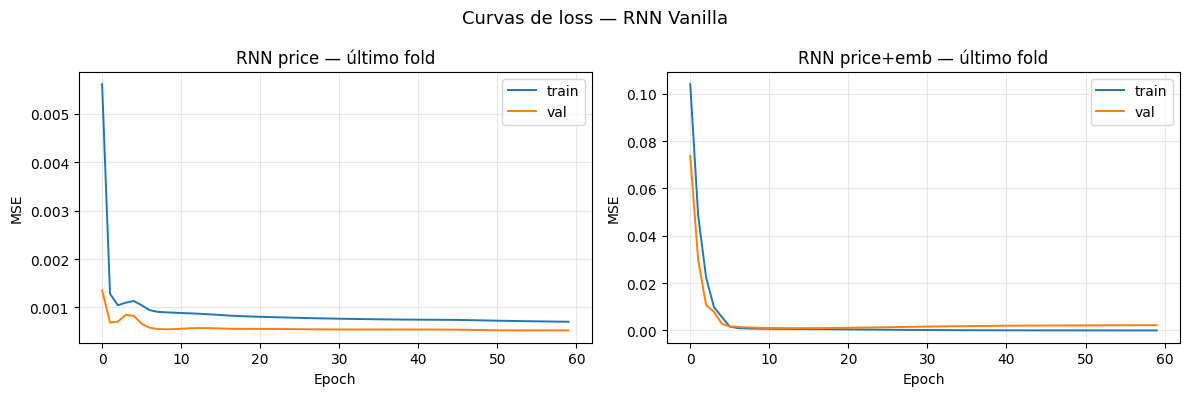

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (key, hist) in zip(axes, fold_histories.items()):
    ax.plot(hist["train"], label="train", linewidth=1.4)
    ax.plot(hist["val"],   label="val",   linewidth=1.4)
    ax.set_title(f"RNN {key} — último fold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE")
    ax.legend()
    ax.grid(alpha=0.3)
plt.suptitle("Curvas de loss — RNN Vanilla", fontsize=13)
plt.tight_layout()
if USE_WANDB:
    wandb.log({"loss_curves": wandb.Image(fig)})
plt.show()

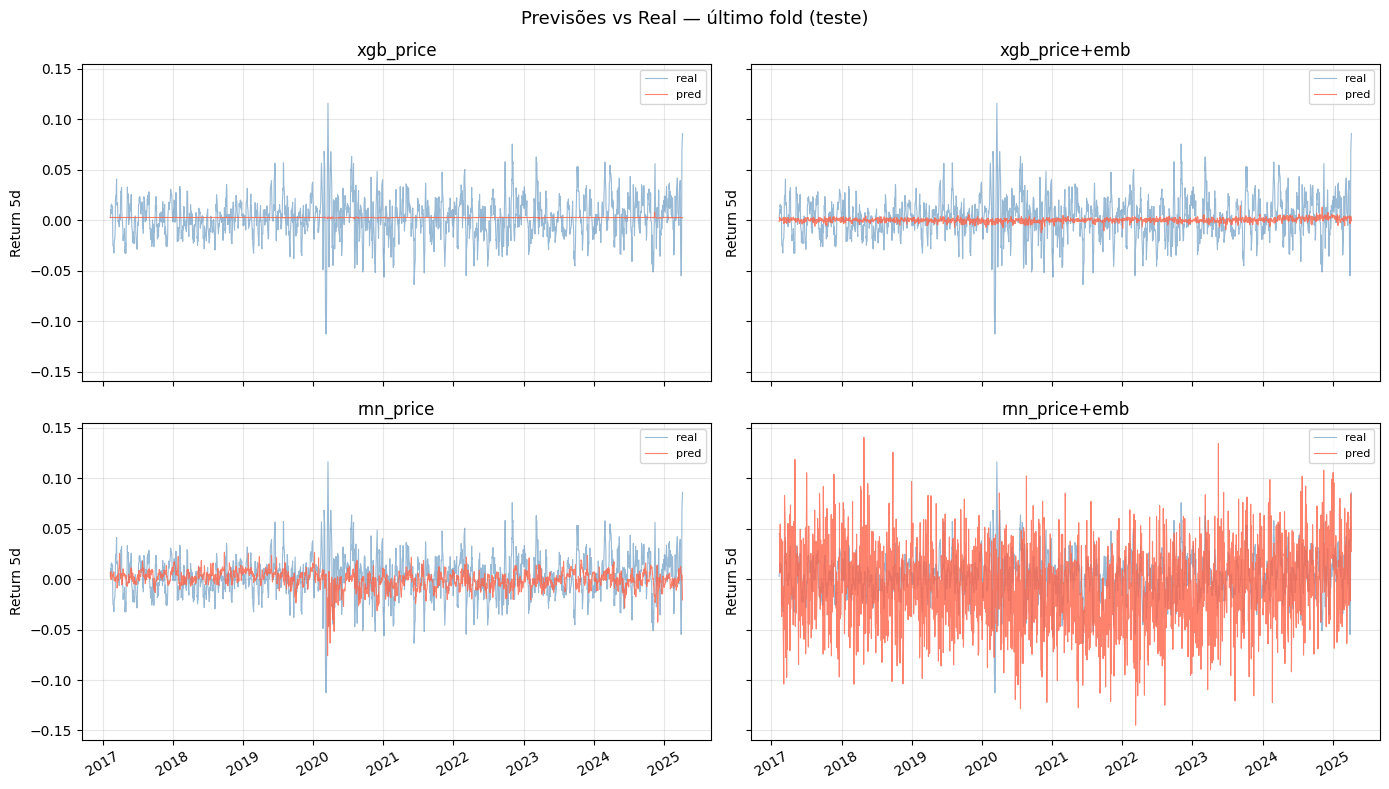

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
for ax, (label, pred) in zip(axes.flat, last_fold_preds.items()):
    ax.plot(last_fold_dates, last_fold_actual, color="steelblue", alpha=0.55,
            linewidth=0.8, label="real")
    ax.plot(last_fold_dates, pred, color="tomato", alpha=0.8,
            linewidth=0.8, label="pred")
    ax.set_title(label)
    ax.set_ylabel("Return 5d")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.tick_params(axis="x", rotation=30)
plt.suptitle("Previsões vs Real — último fold (teste)", fontsize=13)
plt.tight_layout()
if USE_WANDB:
    wandb.log({"predictions_last_fold": wandb.Image(fig)})
plt.show()

/tmp/ipykernel_19046/1624904882.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODEL_ORDER, rotation=35, ha="right", fontsize=9)
/tmp/ipykernel_19046/1624904882.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODEL_ORDER, rotation=35, ha="right", fontsize=9)
/tmp/ipykernel_19046/1624904882.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODEL_ORDER, rotation=35, ha="right", fontsize=9)
/tmp/ipykernel_19046/1624904882.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODEL_ORDER, rotation=35, ha="right", fontsize=9)


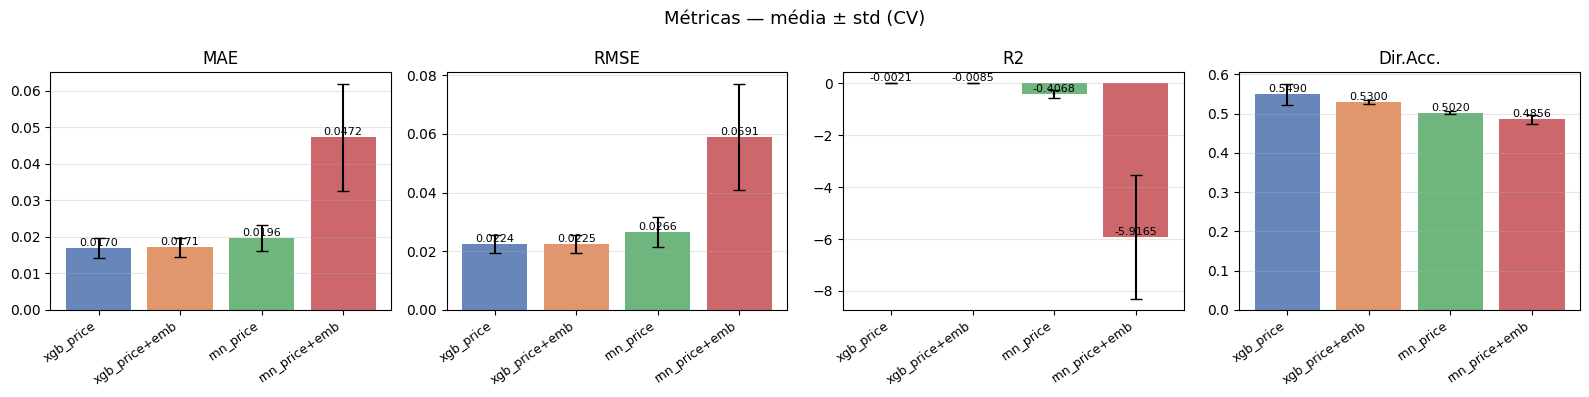

In [16]:
MODEL_ORDER = ["xgb_price", "xgb_price+emb", "rnn_price", "rnn_price+emb"]
COLORS      = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

means = results_df.groupby("modelo")[["MAE", "RMSE", "R2", "Dir.Acc."]].mean().loc[MODEL_ORDER]
stds  = results_df.groupby("modelo")[["MAE", "RMSE", "R2", "Dir.Acc."]].std().loc[MODEL_ORDER]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, ["MAE", "RMSE", "R2", "Dir.Acc."]):
    bars = ax.bar(MODEL_ORDER, means[col], yerr=stds[col], capsize=4,
                  color=COLORS, alpha=0.85, error_kw={"elinewidth": 1.5})
    ax.set_title(col, fontsize=12)
    ax.set_xticklabels(MODEL_ORDER, rotation=35, ha="right", fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, means[col]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{val:.4f}", ha="center", va="bottom", fontsize=8)
plt.suptitle("Métricas — média ± std (CV)", fontsize=13)
plt.tight_layout()
if USE_WANDB:
    wandb.log({"metrics_bar": wandb.Image(fig)})
plt.show()

## 6. Importância de features (último fold)

Share embeddings (xgb_price+emb): 97.35%


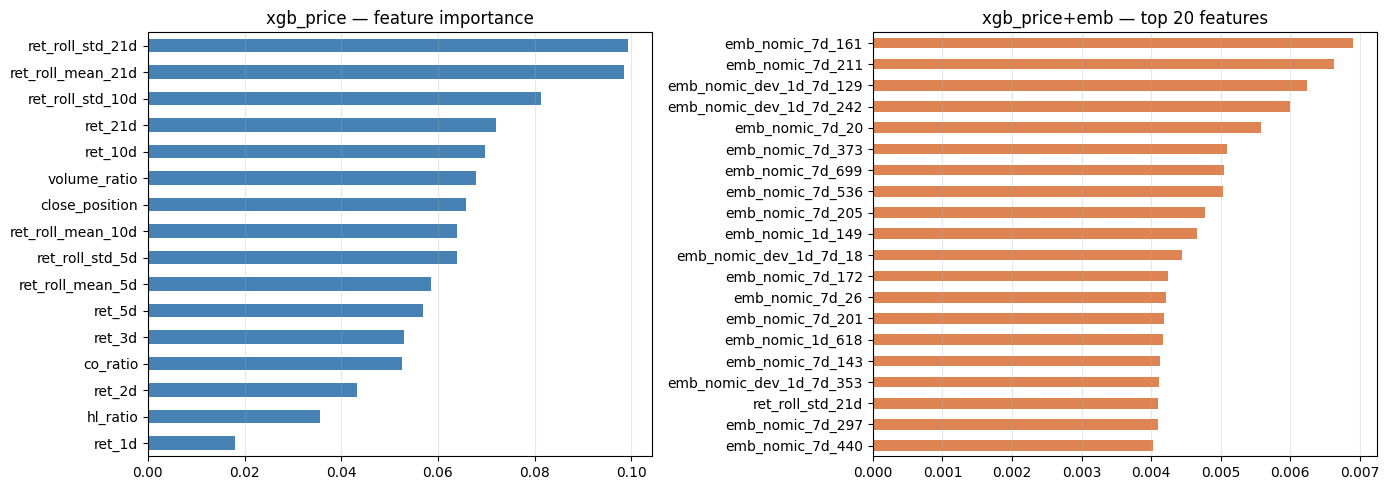

In [17]:
imp_p  = pd.Series(last_xgb_p.feature_importances_,  index=price_features).sort_values(ascending=False)
imp_pe = pd.Series(last_xgb_pe.feature_importances_, index=all_features).sort_values(ascending=False)

emb_share = float(imp_pe[emb_features].sum() / imp_pe.sum())
print(f"Share embeddings (xgb_price+emb): {emb_share:.2%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

imp_p.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].invert_yaxis()
axes[0].set_title("xgb_price — feature importance")
axes[0].grid(axis="x", alpha=0.3)

# Top-20 do modelo com embeddings
imp_pe.head(20).plot(kind="barh", ax=axes[1], color="#DD8452")
axes[1].invert_yaxis()
axes[1].set_title("xgb_price+emb — top 20 features")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
if USE_WANDB:
    wandb.log({"feature_importance": wandb.Image(fig)})
plt.show()

In [18]:
if USE_WANDB:
    wandb.finish()